Para aplicar KNN de manera efectiva, se requiere que todas las variables estén en una escala comparable, ya que el algoritmo depende del cálculo de distancias (Euclidiana o Manhattan). Las variables numéricas (edad_limpia, total_hijos, agr_edad, etc.) se normalizan utilizando MinMaxScaler para acotarlas al rango [0, 1]. Las variables categóricas se transforman a formato binario mediante One-Hot Encoding. Debido a la alta exigencia de memoria RAM de KNN durante la fase de inferencia, se han optimizado los tipos de datos (downcasting a int8 y float32) para reducir la huella de memoria del DataFrame.

In [26]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay, 
                             f1_score, roc_auc_score, RocCurveDisplay)

# PASO 1: EXTRACCIÓN Y PREPROCESAMIENTO (CORREGIDO PARA NaNs)

df_modelado = pd.read_csv("Cuaderno Jupyter para Analisis/Base_Violencia_INE_Unificada_LIMPIA.csv", low_memory=False)

columnas_exploratorio = [
    "edad_limpia",       
    "total_hijos",       
    "vic_escolaridad",   
    "vic_trabaja"        
]

# CORRECCIÓN: Eliminar filas con NA en nuestras variables predictoras o en la variable objetivo
columnas_estrictas = columnas_exploratorio + ["hec_tipagre"]
df_modelado = df_modelado.dropna(subset=columnas_estrictas)

# Crear variable objetivo
df_modelado["riesgo_violencia_fisica"] = df_modelado["hec_tipagre"].str.contains('Físic|Fisic', case=False, na=False)
y = df_modelado["riesgo_violencia_fisica"].astype(np.int8)
X = df_modelado[columnas_exploratorio]

# Optimizar memoria para mi laptop
X = pd.get_dummies(X, drop_first=True)

for col in X.select_dtypes(include=['float64']).columns:
    X[col] = X[col].astype(np.float32)
for col in X.select_dtypes(include=['int64', 'uint8', 'bool']).columns:
    X[col] = X[col].astype(np.int8)

# División Estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Set de entrenamiento (X_train) limpio de NaNs: {X_train.shape}")

Set de entrenamiento (X_train) limpio de NaNs: (358548, 73)


El algoritmo K-Nearest Neighbors presenta una alta complejidad temporal y espacial durante la inferencia, lo que dificulta la optimización de hiperparámetros en conjuntos de datos masivos. Para encontrar la configuración óptima sin exceder los límites de memoria RAM (6GB), se ejecutó un GridSearchCV utilizando una submuestra estratificada del 10% de los datos de entrenamiento (aprox. 36,500 registros). Esta búsqueda evaluó combinaciones del número de vecinos (n_neighbors), la métrica de distancia (p) y la función de peso (weights). Dado que el objetivo es la detección precisa del riesgo de violencia física (reduciendo tanto falsos positivos como falsos negativos), se priorizó la métrica F1-Score Macro para la selección del mejor modelo.

In [30]:

# PASO 2: BÚSQUEDA DE HIPERPARÁMETROS (con muestreo)
# Extraer una submuestra del 10% 
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=0.10, random_state=42, stratify=y_train
)

print(f"Tamaño de la submuestra para GridSearch: {X_tune.shape}")

knn_pipeline = Pipeline([
    ('scaler', MinMaxScaler()), 
    ('knn', KNeighborsClassifier(n_jobs=1)) # n_jobs=1 evita que se duplique el uso de RAM
])

# hiperparámetros a evaluar
param_grid = {
    'knn__n_neighbors': [5, 15, 35],      
    'knn__weights': ['uniform', 'distance'], 
    'knn__p': [1, 2]                      
}

# GridSearchCV
grid_search = GridSearchCV(
    knn_pipeline, 
    param_grid, 
    cv=3,                 
    scoring='f1_macro', 
    n_jobs=1,             
    verbose=2            
)

print("\nIniciando la búsqueda de los mejores hiperparámetros...")
start_time_grid = time.time()

# Ajustar el grid con el muestreo
grid_search.fit(X_tune, y_tune)

tiempo_grid = time.time() - start_time_grid
print(f"\nBúsqueda completada en {tiempo_grid:.2f} segundos.")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")

Tamaño de la submuestra para GridSearch: (35854, 73)

Iniciando la búsqueda de los mejores hiperparámetros...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .knn__n_neighbors=5, knn__p=1, knn__weights=uniform; total time=   9.6s
[CV] END .knn__n_neighbors=5, knn__p=1, knn__weights=uniform; total time=   9.2s
[CV] END .knn__n_neighbors=5, knn__p=1, knn__weights=uniform; total time=   9.2s
[CV] END knn__n_neighbors=5, knn__p=1, knn__weights=distance; total time=   9.1s
[CV] END knn__n_neighbors=5, knn__p=1, knn__weights=distance; total time=   9.1s
[CV] END knn__n_neighbors=5, knn__p=1, knn__weights=distance; total time=   9.0s
[CV] END .knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=   1.4s
[CV] END .knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=   1.7s
[CV] END .knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=   1.4s
[CV] END knn__n_neighbors=5, knn__p=2, knn__weights=distance; total time=   1.7s
[CV] END knn__n_nei

In [31]:
# PASO 3: ENTRENAMIENTO DEL MODELO FINAL

# mejor modelo segun grid
best_knn = grid_search.best_estimator_

print(f"Entrenando el modelo final KNN (K={grid_search.best_params_['knn__n_neighbors']}, "
      f"Distancia={grid_search.best_params_['knn__p']})...")
print("Esto puede tardar unos minutos en ejecutarse...")

start_time = time.time()
# Entrenamos el mejor modelo pero ahora usando TODO el conjunto X_train
best_knn.fit(X_train, y_train)
entrenamiento_time = time.time() - start_time

print(f"Entrenamiento completado en {entrenamiento_time:.2f} segundos.")

Entrenando el modelo final KNN (K=35, Distancia=2)...
Esto puede tardar unos minutos en ejecutarse...
Entrenamiento completado en 0.27 segundos.



Realizando predicciones en el set de prueba (156,587 registros)...
Predicciones completadas en 470.79 segundos.

REPORTE GLOBAL DEL MODELO KNN
Accuracy en Test:     0.6006
F1-Score Macro:       0.5916

REPORTE DETALLADO DE CLASIFICACIÓN:
               precision    recall  f1-score   support

No Físico (0)       0.57      0.49      0.53     70375
   Físico (1)       0.62      0.69      0.65     83289

     accuracy                           0.60    153664
    macro avg       0.60      0.59      0.59    153664
 weighted avg       0.60      0.60      0.60    153664



/home/jfmg/Documents/UVG/mineria-datos/proyecto_01_mineria_datos/venv/lib64/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


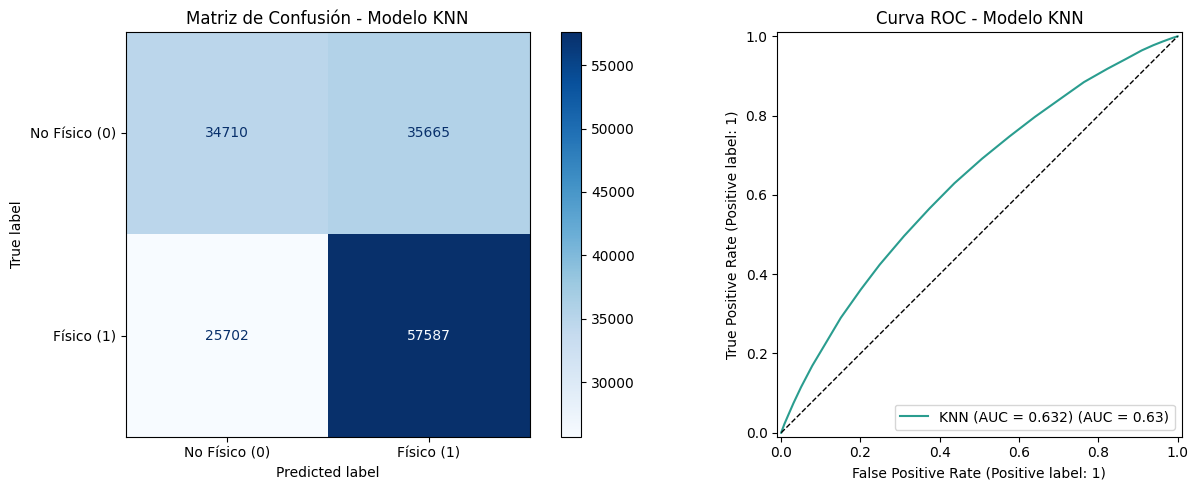

In [32]:
# PASO 4: EVALUACIÓN Y GRÁFICAS
print("\nRealizando predicciones en el set de prueba (156,587 registros)...")
start_pred = time.time()

# Predecimos la clase 0 o 1 y la probabilidad
y_pred_knn = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

prediccion_time = time.time() - start_pred
print(f"Predicciones completadas en {prediccion_time:.2f} segundos.")

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_macro_knn = f1_score(y_test, y_pred_knn, average="macro")

print("\n" + "="*40)
print("REPORTE GLOBAL DEL MODELO KNN")
print("="*40)
print(f"Accuracy en Test:     {acc_knn:.4f}")
print(f"F1-Score Macro:       {f1_macro_knn:.4f}")
print("\nREPORTE DETALLADO DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_knn, target_names=["No Físico (0)", "Físico (1)"]))

# Graficas
plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_knn, 
    display_labels=["No Físico (0)", "Físico (1)"], 
    cmap="Blues", 
    ax=axes[0]
)
axes[0].set_title("Matriz de Confusión - Modelo KNN")

# Gráfico 2: Curva ROC
auc_score = roc_auc_score(y_test, y_prob_knn)
RocCurveDisplay.from_predictions(
    y_test, 
    y_prob_knn, 
    name=f"KNN (AUC = {auc_score:.3f})", 
    color="#2A9D8F", 
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1) # Línea diagonal de referencia
axes[1].set_title("Curva ROC - Modelo KNN")

plt.tight_layout()
plt.show()

Tras el entrenamiento y evaluación del modelo K-Nearest Neighbors optimizado, se extraen las siguientes conclusiones sobre la viabilidad de predecir el riesgo de violencia física utilizando exclusivamente variables demográficas y socioeconómicas (edad, número de hijos, escolaridad y condición laboral):
* Rendimiento Computacional y Escalabilidad: El modelo requirió 485.99 segundos únicamente para realizar las predicciones sobre el conjunto de prueba (156,587 registros). Esto demuestra empíricamente la principal limitación de KNN: su altísima complejidad espacial y temporal durante la fase de inferencia. Para un sistema en tiempo real, este costo computacional lo hace menos viable frente a algoritmos paramétricos o basados en árboles.

* Desempeño Global (Accuracy y AUC): Se obtuvo un Accuracy global del 60.06% y un Área Bajo la Curva (AUC) de 0.632. Aunque el modelo logra separar las clases mejor que el azar (0.5), estas métricas indican que el espacio de características demográficas tiene un alto nivel de superposición. Las variables seleccionadas, por sí solas, no contienen suficiente varianza explicativa para trazar una frontera de decisión perfecta entre la violencia física y otros tipos de violencia (como la psicológica).

* Priorización de la Clase Positiva (Recall): Desde la perspectiva del problema científico y la utilidad social del modelo, el hallazgo más valioso es el Recall del 69% para la Clase 1 (Físico). De los 83,289 casos reales de violencia física en el set de prueba, el algoritmo logró identificar correctamente 57,587 (Verdaderos Positivos). En contextos de riesgo vital, priorizar una alta sensibilidad (Recall) es fundamental para evitar omitir a víctimas en peligro inminente.

* Análisis de Errores (Falsos Positivos): Al observar la matriz de confusión, es evidente que el modelo "peca de precavido". Generó 35,665 Falsos Positivos (casos no físicos clasificados como físicos). Esta es la causa del bajo Precision en la clase 0 (57%). El algoritmo tiende a generalizar el perfil de la víctima de violencia física, absorbiendo casos de violencia psicológica o patrimonial que comparten características demográficas similares (como la edad o la dependencia económica).

Conclusión: KNN logra perfilar una línea base aceptable para la detección de riesgo físico basándose en la proximidad demográfica de las víctimas. Sin embargo, para mejorar la precisión y reducir los falsos positivos, será indispensable en futuras iteraciones incorporar variables relacionadas con el agresor o el contexto institucional, y migrar hacia modelos ensamblados que manejen mejor las relaciones no lineales.